<a href="https://colab.research.google.com/github/pachterlab/cellsweep/blob/main/benchmarking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# try:
#     from cellsweep import denoise_count_matrix
# except ImportError:
#     print("cellsweep not found, installing...")
#     !pip install -U -q cellsweep[analysis]

In [ ]:
import os
import numpy as np
import itertools
from cellsweep import denoise_count_matrix
import cellsweep.utils as cs_utils

cellsweep_dir = os.path.dirname(os.path.abspath(""))
rver_docker_workspace = "/home/ruser/work/cellsweep"

# nac workflow

In [3]:
dataset_name = "pbmc8k"  # options: pbmc8k
verbose = 2  # 2 debug, 1 info, 0 warning, -1 error, -2 critical
overwrite = False  # overwrite existing files
threads = 32  # for cellsweep and CellBender (if use_cuda=False)
docker = "podman"  # "docker" or "podman" - if podman, then run `sudo setenforce 0` to disable SELinux enforcement before the podman commands

In [4]:
data_dir = os.path.join(cellsweep_dir, "notebooks", "data", dataset_name)
os.makedirs(data_dir, exist_ok=True)

out_dir = os.path.join(cellsweep_dir, "notebooks", "output", dataset_name)
os.makedirs(out_dir, exist_ok=True)

if dataset_name == "pbmc8k":
    leiden_resolution = 1.0
else:
    raise ValueError(f"Unknown dataset_name: {dataset_name}")

adata_path_raw = f"{data_dir}/kb_count_out_nac/counts_unfiltered/adata.h5ad"
adata_types = ["spliced", "unspliced", "ambiguous"]

In [5]:
# !cd {data_dir} && wget https://s3-us-west-2.amazonaws.com/10x.files/samples/cell-exp/2.1.0/pbmc8k/pbmc8k_fastqs.tar && tar -xvf pbmc8k_fastqs.tar
fastqs_sorted = sorted([os.path.join(data_dir, "fastqs", f) for f in os.listdir(os.path.join(data_dir, "fastqs")) if f.endswith(".fastq.gz") and "I1" not in f])
fastqs_sorted = " ".join(fastqs_sorted)

data_dir_parent = os.path.dirname(data_dir)
kb_ref_out_nac = os.path.join(data_dir_parent, "kb_ref_out_nac")
os.makedirs(kb_ref_out_nac, exist_ok=True)
!echo kb ref -i {kb_ref_out_nac}/index.idx -g {kb_ref_out_nac}/t2g.txt -f1 {kb_ref_out_nac}/f1.fa -f2 {kb_ref_out_nac}/f2.fa -c1 {kb_ref_out_nac}/c1.txt -c2 {kb_ref_out_nac}/c2.txt --workflow nac -d human
!echo kb count -i {kb_ref_out_nac}/index.idx -g {kb_ref_out_nac}/t2g.txt -x 10XV2 -c1 {kb_ref_out_nac}/c1.txt -c2 {kb_ref_out_nac}/c2.txt --workflow nac --h5ad -t {threads} -o {data_dir}/kb_count_out_nac {fastqs_sorted}

kb ref -i /home/jrich/Desktop/cellsweep/notebooks/data/kb_ref_out_nac/index.idx -g /home/jrich/Desktop/cellsweep/notebooks/data/kb_ref_out_nac/t2g.txt -f1 /home/jrich/Desktop/cellsweep/notebooks/data/kb_ref_out_nac/f1.fa -f2 /home/jrich/Desktop/cellsweep/notebooks/data/kb_ref_out_nac/f2.fa -c1 /home/jrich/Desktop/cellsweep/notebooks/data/kb_ref_out_nac/c1.txt -c2 /home/jrich/Desktop/cellsweep/notebooks/data/kb_ref_out_nac/c2.txt --workflow nac -d human
kb count -i /home/jrich/Desktop/cellsweep/notebooks/data/kb_ref_out_nac/index.idx -g /home/jrich/Desktop/cellsweep/notebooks/data/kb_ref_out_nac/t2g.txt -x 10XV2 -c1 /home/jrich/Desktop/cellsweep/notebooks/data/kb_ref_out_nac/c1.txt -c2 /home/jrich/Desktop/cellsweep/notebooks/data/kb_ref_out_nac/c2.txt --workflow nac --h5ad -t 32 -o /home/jrich/Desktop/cellsweep/notebooks/data/pbmc8k/kb_count_out_nac /home/jrich/Desktop/cellsweep/notebooks/data/pbmc8k/fastqs/pbmc8k_S1_L007_R1_001.fastq.gz /home/jrich/Desktop/cellsweep/notebooks/data/pbmc

## Knee plot - use this output to estimate umi_cutoff

In [6]:
adata_raw = cs_utils.load_adata(adata_path_raw)
adata_raw.var_names_make_unique()

adata_spliced = adata_raw.copy()
adata_spliced.X = adata_raw.layers["mature"]

adata_unspliced = adata_raw.copy()
adata_unspliced.X = adata_raw.layers["nascent"]

adata_ambiguous = adata_raw.copy()
adata_ambiguous.X = adata_raw.layers["ambiguous"]

adata_dict = {}
adata_dict["raw_spliced"] = adata_spliced
adata_dict["raw_unspliced"] = adata_unspliced
adata_dict["raw_ambiguous"] = adata_ambiguous

del adata_raw  # avoid confusion

UMI cutoff for expected cells (8381): 460.00
UMI cutoff for expected cells (8381): 520.00
UMI cutoff for expected cells (8381): 926.00


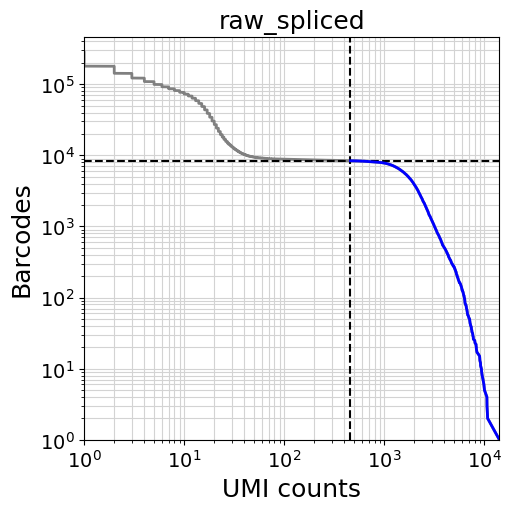

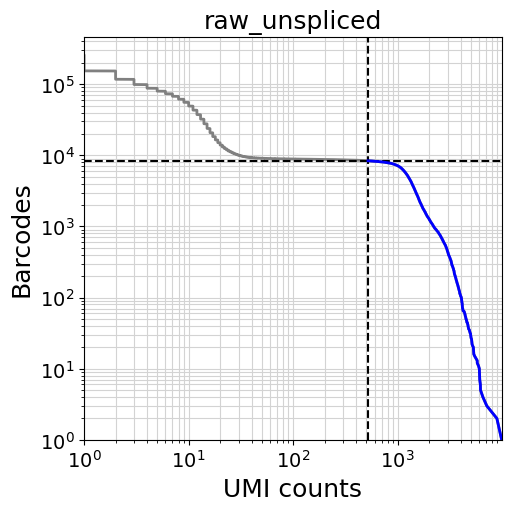

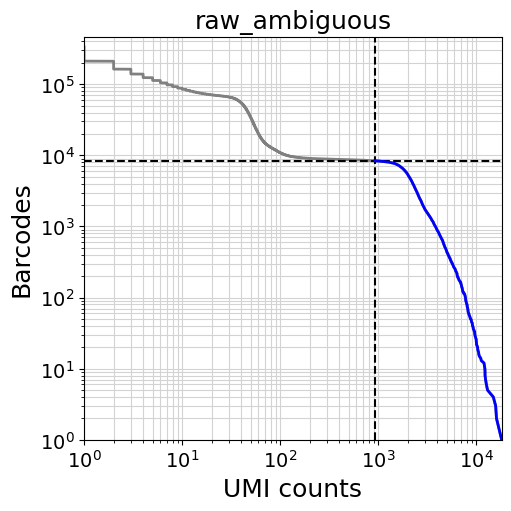

In [7]:
for adata_name, adata in adata_dict.items():
    expected_cells = 8381
    umi_cutoff = cs_utils.knee_plot(adata, transpose=True, expected_cells=expected_cells, title=adata_name, out_path=os.path.join(out_dir, f"knee_plot_{adata_name}.png"))
    adata = cs_utils.infer_empty_droplets(adata, method="threshold", umi_cutoff=umi_cutoff, verbose=verbose)  # adds adata.obs["is_empty"]
    adata.var['empty_counts'] = np.array(adata.X[adata.obs['is_empty'].values, :].sum(axis=0)).flatten()
    adata_dict[adata_name] = adata

## cellsweep

In [8]:
for adata_name in adata_types:
    adata_path_cellsweep = os.path.join(data_dir, f"adata_cellsweep_{adata_name}.h5ad")
    cellsweep_log_file = os.path.join(data_dir, f"cellsweep_{adata_name}.log")
    if not os.path.exists(adata_path_cellsweep) or overwrite:
        adata = adata_dict[f"raw_{adata_name}"].copy()
        if "celltype" not in adata.obs.columns:
            adata_processed_tmp = adata[~adata.obs["is_empty"]].copy()
            adata_processed_tmp = cs_utils.run_scanpy_preprocessing_and_clustering(adata_processed_tmp, min_genes=None, min_cells=None, max_mt_percentage=None, n_top_genes=2000, n_pcs=50, n_neighbors=15, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
            adata.obs["celltype"] = adata_processed_tmp.obs["leiden"].reindex(adata.obs.index).astype(str).replace("nan", "empty").astype("category")
        adata_cellsweep = denoise_count_matrix(adata, init_alpha=0.9, beta=0.1, adata_out=adata_path_cellsweep, freeze_ambient_profile=True, empty_droplet_method="threshold", threads=threads, verbose=verbose, log_file=cellsweep_log_file)
    else:
        adata_cellsweep = cs_utils.load_adata(adata_path_cellsweep, verbose=verbose)
    
    adata_cellsweep = adata_cellsweep[~adata_cellsweep.obs["is_empty"]].copy()
    adata_cellsweep.var_names_make_unique()
    adata_dict[f"cellsweep_{adata_name}"] = adata_cellsweep

11:35:40 - INFO - Adata initial shape: (8381, 39546)
11:35:40 - INFO - 'counts' layer not found in adata. Creating 'counts' layer from adata.X and normalizing total counts to 1e4. This is done by copying the raw count matrix into a new layer called 'counts' and then applying total-count normalization to ensure that each cell has the same total count (e.g., 10,000). This step is important for downstream analyses that assume normalized data.
11:35:40 - INFO - 'log1p' not found in adata.uns. Applying log1p transformation to adata.X and storing in 'log1p' layer. This transformation is commonly used to stabilize variance and make the data more normally distributed, which can improve the performance of downstream analyses such as PCA and clustering.
11:35:40 - INFO - Identifying highly variable genes using 'highly_variable_genes' function. This step identifies the top 2000 genes that show the most variability across cells, which are often the most informative for downstream analyses like clu

Logging to /home/jrich/Desktop/cellsweep/notebooks/data/pbmc8k/cellsweep_spliced.log


11:36:23 - INFO - EM Iter   1: ll=-246.171 log_delta_p=inf min_alpha=0.7861 mean_alpha=0.8794 median_alpha=0.8869 max_alpha=0.9000 beta=0.101541
11:36:23 - DEBUG - 2 cells want to exceed alpha_n > 0.9. They will be excluded from update of p_k and allowed cell-type reassignment
11:36:28 - INFO - EM Iter   2: ll=-245.363 log_delta_p=inf min_alpha=0.6034 mean_alpha=0.8459 median_alpha=0.8666 max_alpha=0.9000 beta=0.101933
11:36:28 - DEBUG - 6 cells want to exceed alpha_n > 0.9. They will be excluded from update of p_k and allowed cell-type reassignment
11:36:28 - INFO - EM Iter   3: ll=-244.679 log_delta_p=-1.1854 min_alpha=0.4577 mean_alpha=0.8160 median_alpha=0.8465 max_alpha=0.9000 beta=0.101869
11:36:28 - DEBUG - 21 cells want to exceed alpha_n > 0.9. They will be excluded from update of p_k and allowed cell-type reassignment
11:36:28 - INFO - EM Iter   4: ll=-244.346 log_delta_p=-1.7736 min_alpha=0.3822 mean_alpha=0.7918 median_alpha=0.8261 max_alpha=0.9000 beta=0.101764
11:36:28 - D

Logging to /home/jrich/Desktop/cellsweep/notebooks/data/pbmc8k/cellsweep_unspliced.log


11:37:11 - INFO - Performing Sparse EM with 32 Numba thread(s)
11:37:12 - INFO - EM Iter   1: ll=-260.611 log_delta_p=inf min_alpha=0.7893 mean_alpha=0.8678 median_alpha=0.8721 max_alpha=0.9000 beta=0.103180
11:37:12 - DEBUG - 1 cells want to exceed alpha_n > 0.9. They will be excluded from update of p_k and allowed cell-type reassignment
11:37:12 - INFO - EM Iter   2: ll=-259.730 log_delta_p=inf min_alpha=0.6518 mean_alpha=0.8152 median_alpha=0.8245 max_alpha=0.9000 beta=0.104531
11:37:12 - DEBUG - 1 cells want to exceed alpha_n > 0.9. They will be excluded from update of p_k and allowed cell-type reassignment
11:37:12 - INFO - EM Iter   3: ll=-258.909 log_delta_p=-1.3917 min_alpha=0.5530 mean_alpha=0.7614 median_alpha=0.7708 max_alpha=0.9000 beta=0.104938
11:37:12 - DEBUG - 1 cells want to exceed alpha_n > 0.9. They will be excluded from update of p_k and allowed cell-type reassignment
11:37:12 - INFO - EM Iter   4: ll=-258.400 log_delta_p=-1.9639 min_alpha=0.4831 mean_alpha=0.7134 m

Logging to /home/jrich/Desktop/cellsweep/notebooks/data/pbmc8k/cellsweep_ambiguous.log


11:37:57 - INFO - adata.obs does not have 'cell_ambient_fraction'. Setting to `cell_ambient_fraction` argument.
11:37:58 - INFO - Performing Sparse EM with 32 Numba thread(s)
11:37:58 - INFO - EM Iter   1: ll=-395.242 log_delta_p=inf min_alpha=0.5864 mean_alpha=0.8653 median_alpha=0.8681 max_alpha=0.9000 beta=0.104212
11:37:58 - DEBUG - 2 cells want to exceed alpha_n > 0.9. They will be excluded from update of p_k and allowed cell-type reassignment
11:37:58 - INFO - EM Iter   2: ll=-393.891 log_delta_p=inf min_alpha=0.1849 mean_alpha=0.8099 median_alpha=0.8143 max_alpha=0.9000 beta=0.106983
11:37:58 - DEBUG - 2 cells want to exceed alpha_n > 0.9. They will be excluded from update of p_k and allowed cell-type reassignment
11:37:58 - INFO - EM Iter   3: ll=-392.390 log_delta_p=-1.3467 min_alpha=0.0774 mean_alpha=0.7544 median_alpha=0.7572 max_alpha=0.9000 beta=0.108430
11:37:58 - DEBUG - 3 cells want to exceed alpha_n > 0.9. They will be excluded from update of p_k and allowed cell-type 

## Analysis

### Raw vs cellsweep knee plot, scatterplots

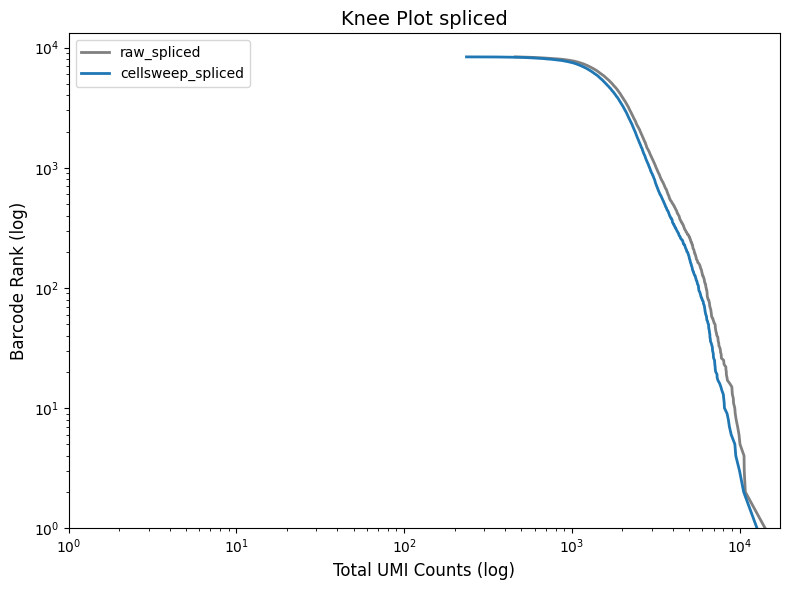

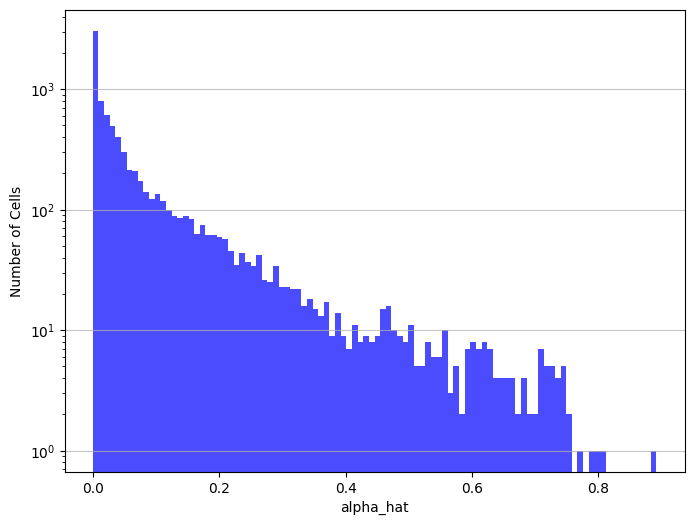

Extracting all nonzero pairs from sparse matrices...
Creating scatterplot...
Calculating scatterplot...


/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


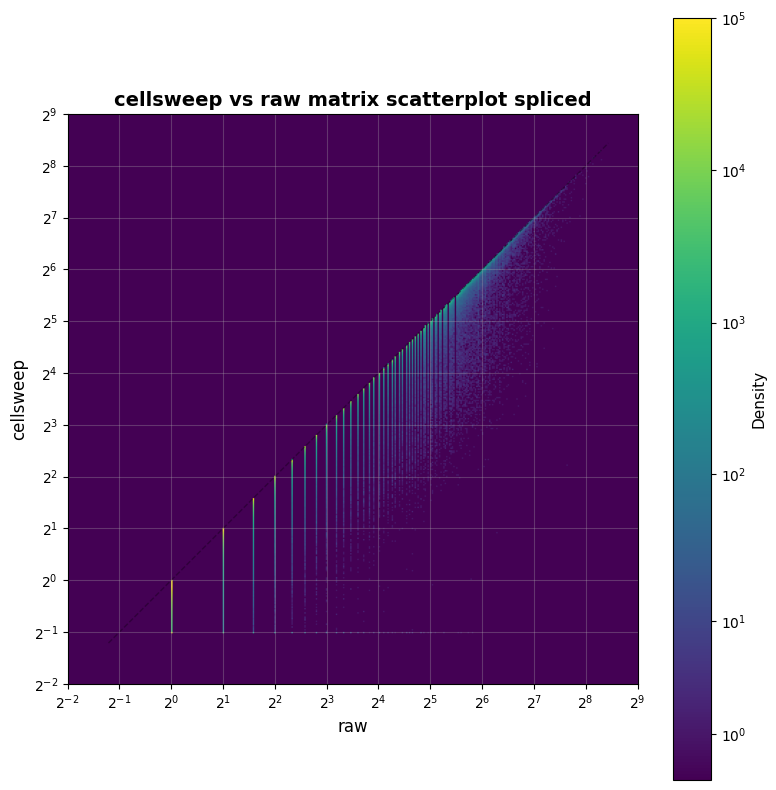

Creating scatterplot...
Calculating scatterplot...


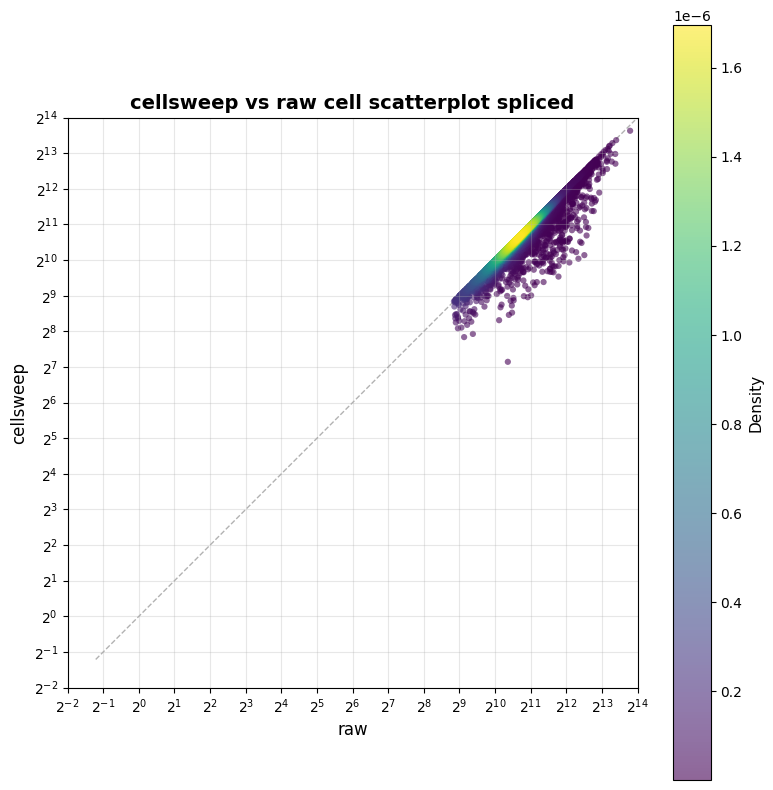

Creating scatterplot...
Calculating scatterplot...


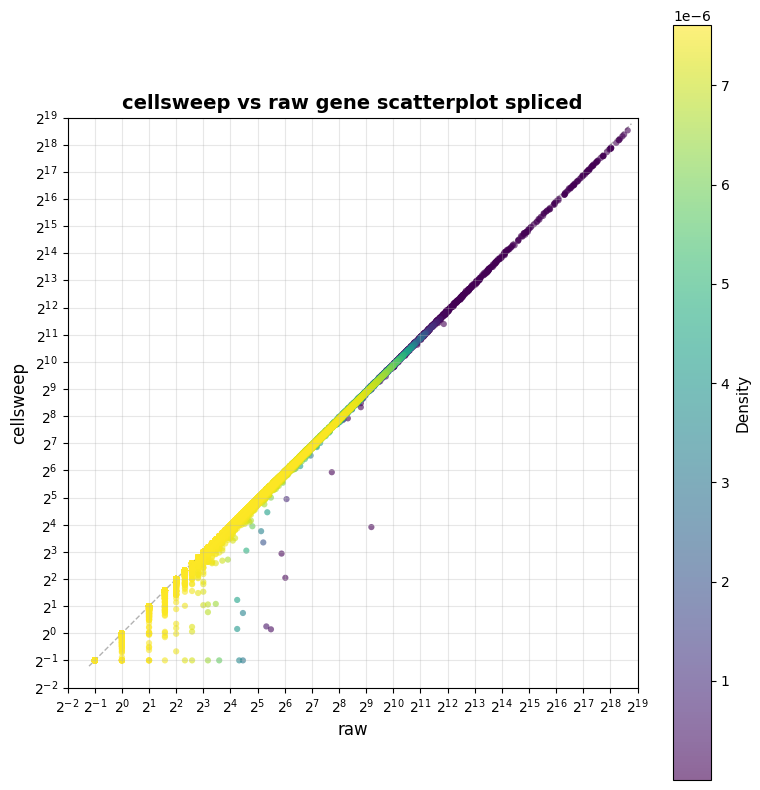

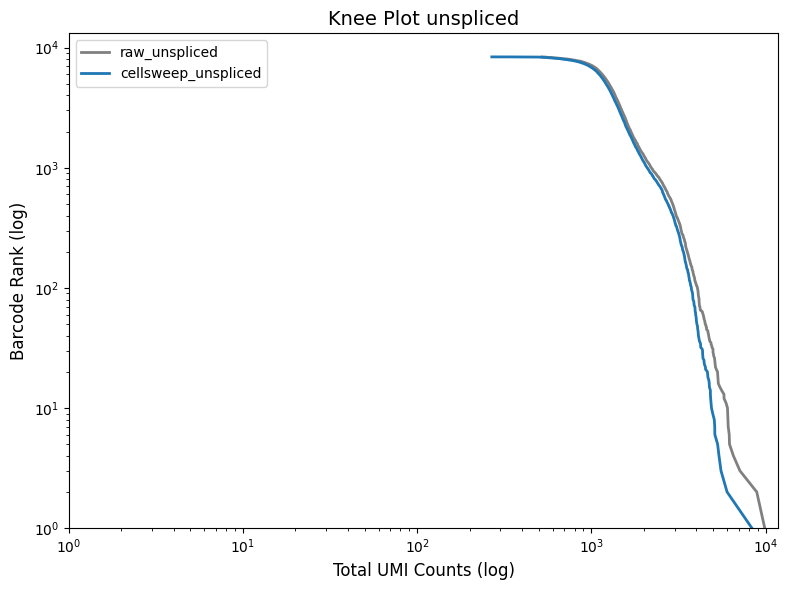

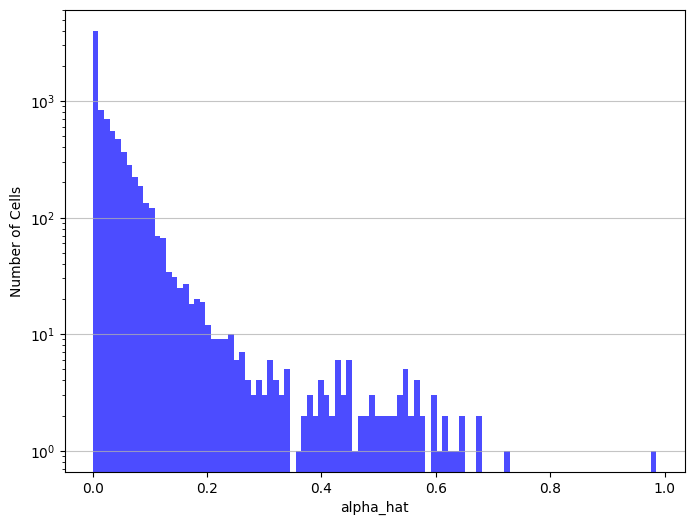

Extracting all nonzero pairs from sparse matrices...
Creating scatterplot...
Calculating scatterplot...


/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


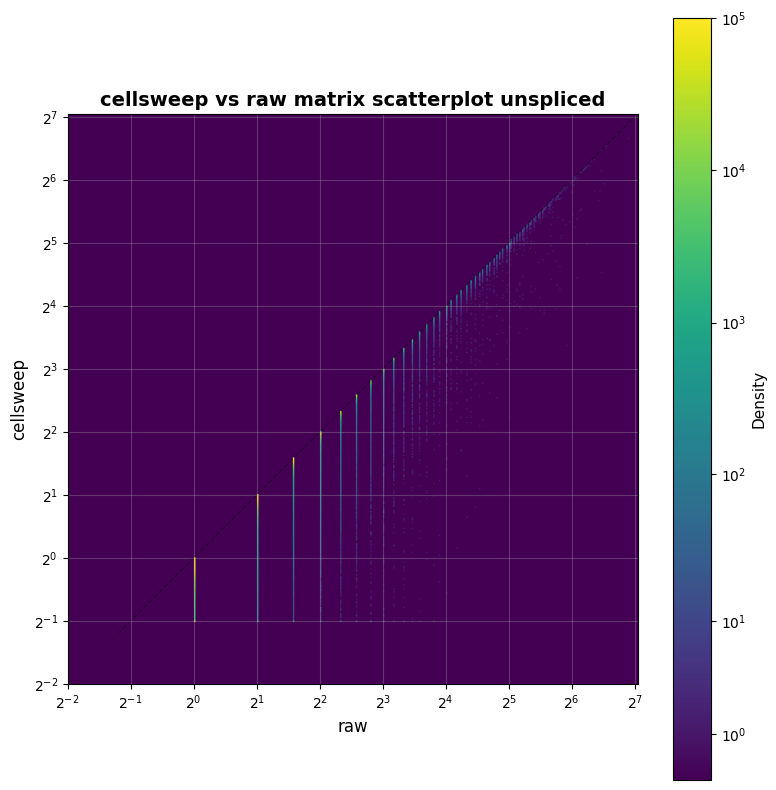

Creating scatterplot...
Calculating scatterplot...


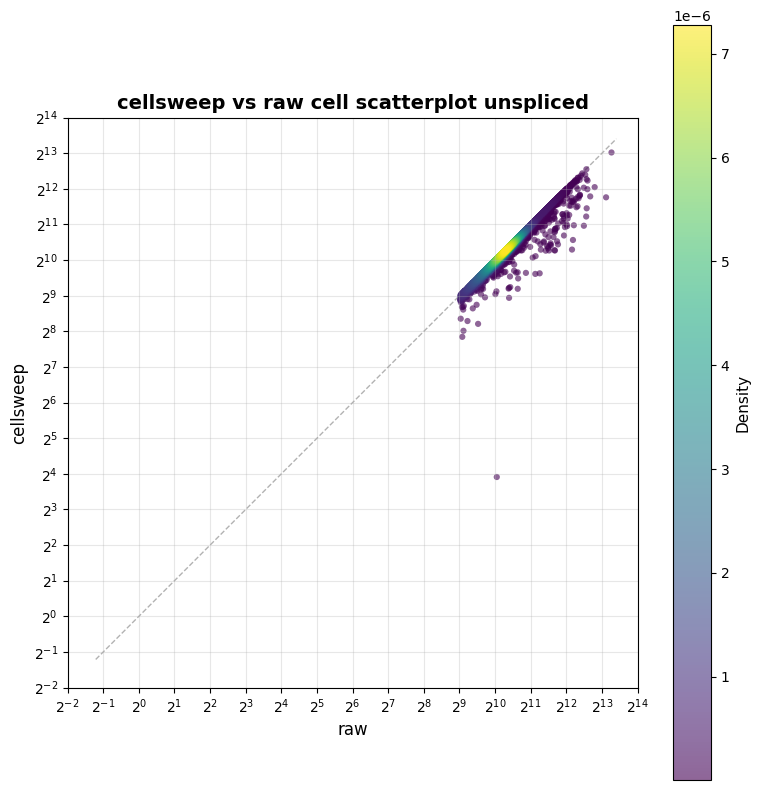

Creating scatterplot...
Calculating scatterplot...


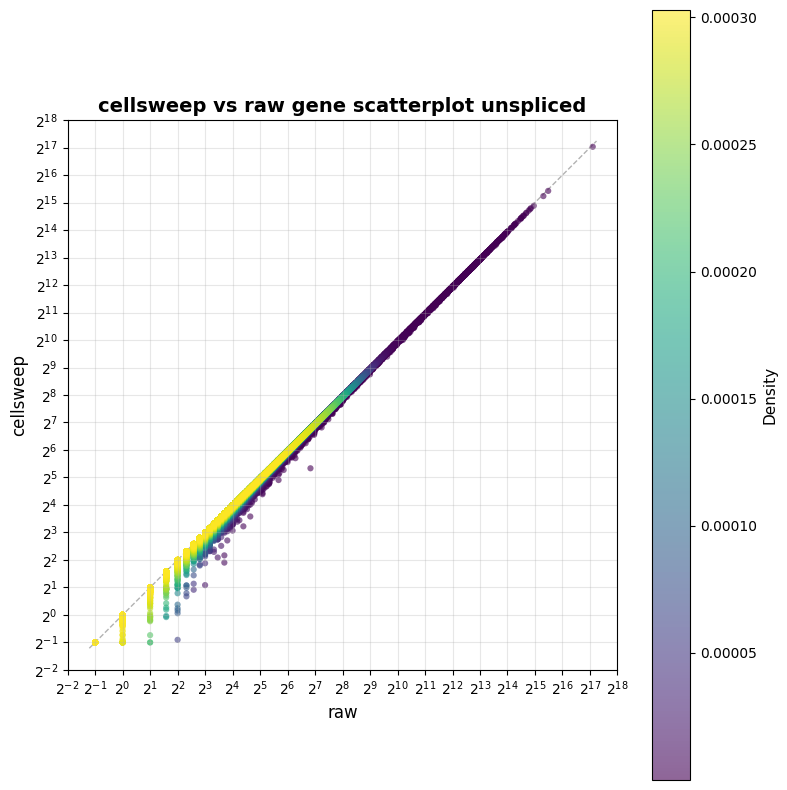

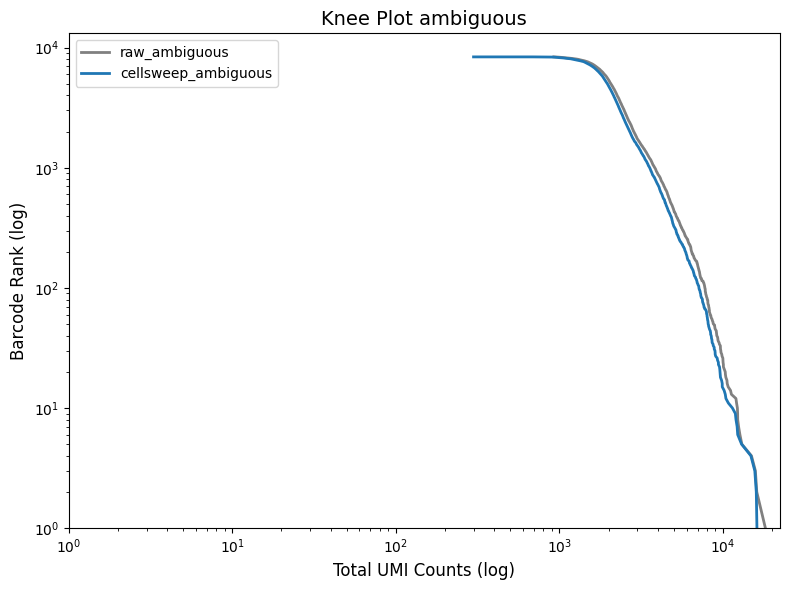

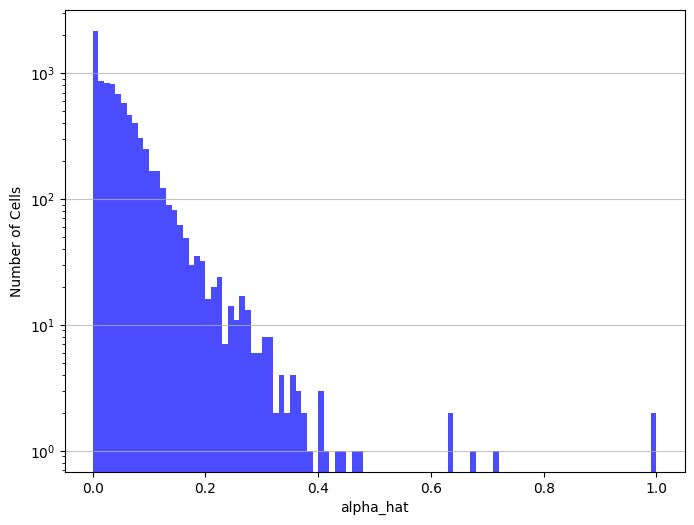

Extracting all nonzero pairs from sparse matrices...
Creating scatterplot...
Calculating scatterplot...


/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


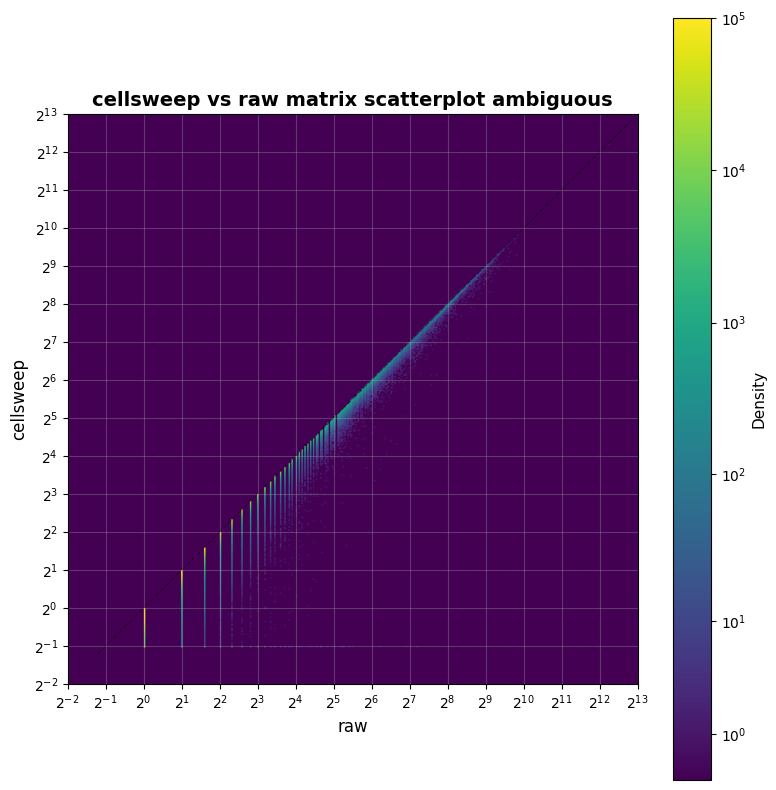

Creating scatterplot...
Calculating scatterplot...


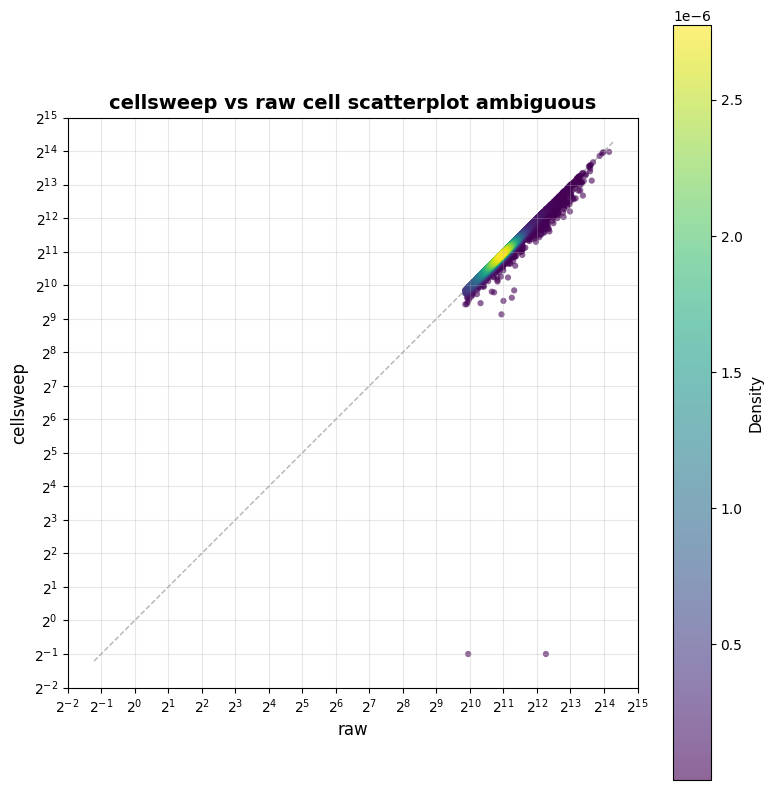

Creating scatterplot...
Calculating scatterplot...


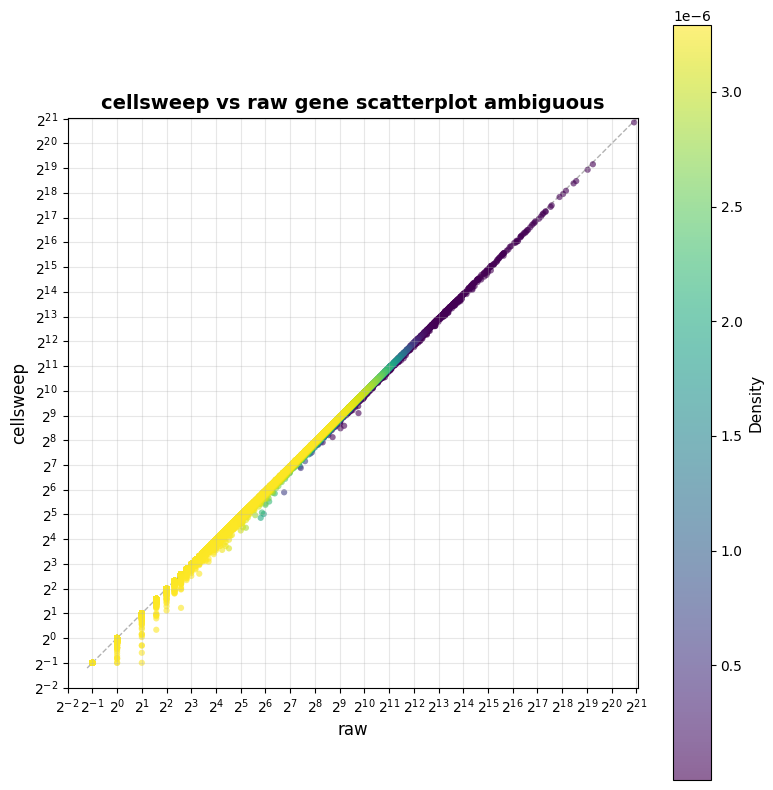

In [9]:
for adata_name in adata_types:
    adata_raw = adata_dict[f"raw_{adata_name}"]
    adata_cellsweep = adata_dict[f"cellsweep_{adata_name}"]
    
    cs_utils.plot_knee_multi([adata_raw, adata_cellsweep], labels=[f"raw_{adata_name}", f"cellsweep_{adata_name}"], title=f"Knee Plot {adata_name}", filter_empty=True, transpose=True, out_path=os.path.join(out_dir, f"cellsweep_knee_plot_{adata_name}.png"))
    cs_utils.plot_histogram(adata_cellsweep, col="alpha_hat", out_path=os.path.join(out_dir, f"alpha_hat_histogram_{adata_name}.png"), ylog=True)

    cs_utils.plot_matrix_scatterplot(adata_raw, adata_cellsweep, point_type="matrix", density_type="scatter_with_density", scale="log", x_axis="raw", y_axis="cellsweep", title=f"cellsweep vs raw matrix scatterplot {adata_name}", out_path=os.path.join(out_dir, f"matrix_expression_scatterplot_{adata_name}.png"), show=True)
    cs_utils.plot_matrix_scatterplot(adata_raw, adata_cellsweep, point_type="cell", density_type="scatter_with_kde", scale="log", x_axis="raw", y_axis="cellsweep", title=f"cellsweep vs raw cell scatterplot {adata_name}", out_path=os.path.join(out_dir, f"cell_expression_scatterplot_{adata_name}.png"), show=True)
    cs_utils.plot_matrix_scatterplot(adata_raw, adata_cellsweep, point_type="gene", density_type="scatter_with_kde", scale="log", x_axis="raw", y_axis="cellsweep", title=f"cellsweep vs raw gene scatterplot {adata_name}", out_path=os.path.join(out_dir, f"gene_expression_scatterplot_{adata_name}.png"), show=True)

## Intron analysis

Plotting ambient_hat scatterplot: spliced vs unspliced
Creating scatterplot...
Calculating scatterplot...


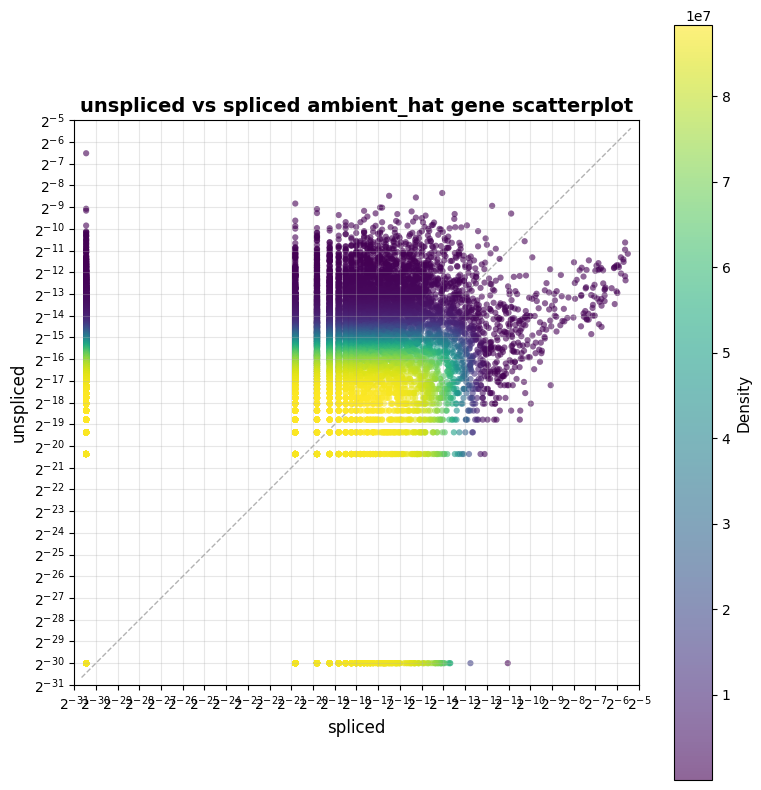

Plotting ambient_hat scatterplot: spliced vs ambiguous
Creating scatterplot...
Calculating scatterplot...


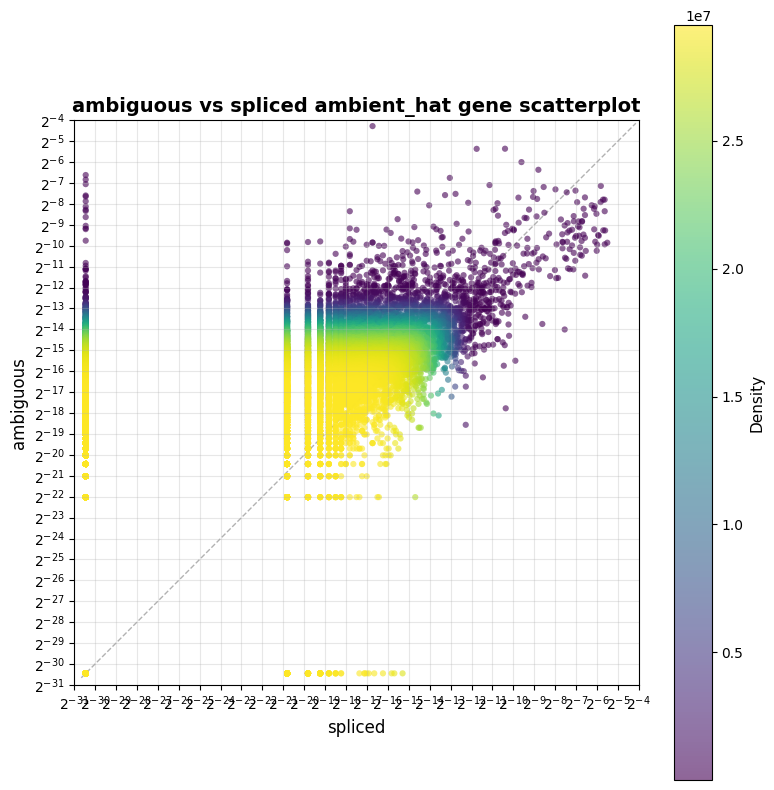

Plotting ambient_hat scatterplot: unspliced vs ambiguous
Creating scatterplot...
Calculating scatterplot...


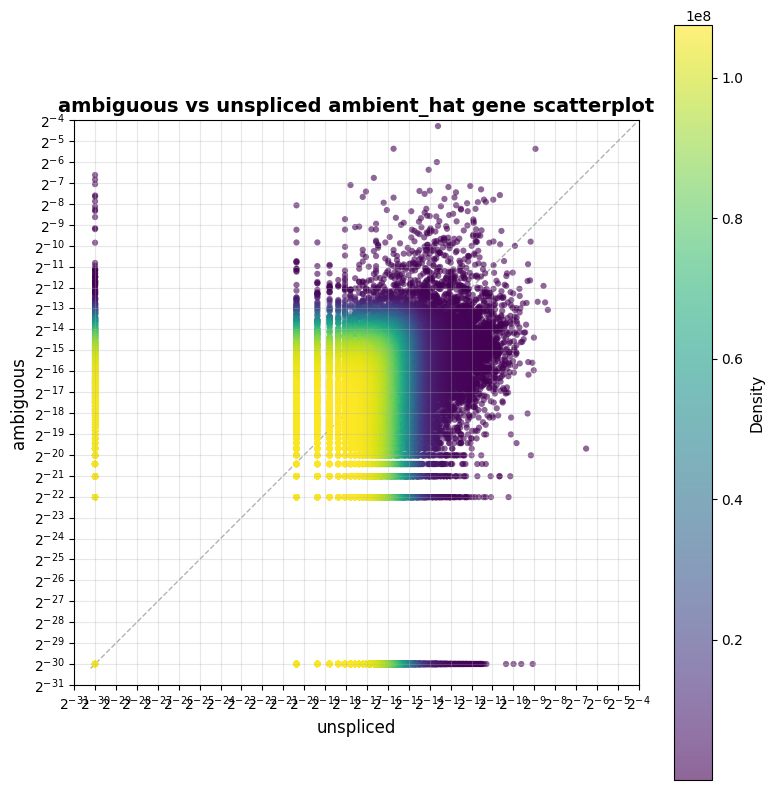

In [10]:
for adata_name1, adata_name2 in itertools.combinations(adata_types, 2):
    print(f"Plotting ambient_hat scatterplot: {adata_name1} vs {adata_name2}")
    s = adata_dict[f"cellsweep_{adata_name1}"].var["ambient_hat"]
    nonzero_min = s[s > 0].min()
    cs_utils.plot_matrix_scatterplot(adata_dict[f"cellsweep_{adata_name1}"].var["ambient_hat"], adata_dict[f"cellsweep_{adata_name2}"].var["ambient_hat"], minimum=nonzero_min, point_type="custom", density_type="scatter_with_kde", scale="log", x_axis=adata_name1, y_axis=adata_name2, title=f"{adata_name2} vs {adata_name1} ambient_hat gene scatterplot", out_path=os.path.join(out_dir, f"{adata_name1}_vs_{adata_name2}_ambient_hat_scatterplot.png"), show=True)

ambiguous cell contamination AUC: 83.80999999996725
spliced cell contamination AUC: 74.73392325542017
unspliced cell contamination AUC: 82.60912496255082


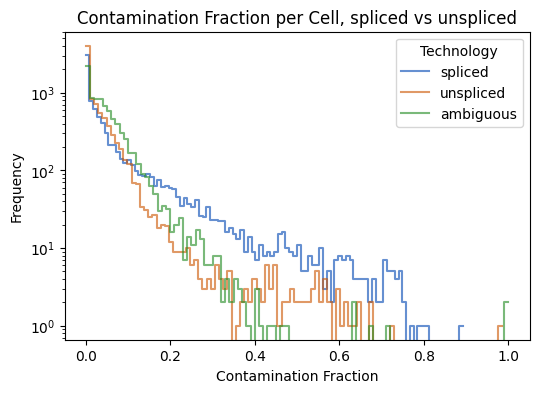

In [11]:
cs_utils.plot_multi_histogram(df1=adata_dict[f"cellsweep_{adata_types[0]}"].obs, df2=adata_dict[f"cellsweep_{adata_types[1]}"].obs, df3=adata_dict[f"cellsweep_{adata_types[2]}"].obs, plotting_column="alpha_hat", df1_name=adata_types[0], df2_name=adata_types[1], df3_name=adata_types[2], out_path=os.path.join(out_dir, "cell_empty_fraction_histogram.png"), show=True)

In [12]:
import pandas as pd
df = pd.read_csv("/home/jrich/data/radiogenomics/general/genomics/variants/mc3.v0.2.8.PUBLIC.maf.gz", sep="\t", compression="gzip")  # , nrows=1000)

/tmp/ipykernel_1406439/129765087.py:2: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/home/jrich/data/radiogenomics/general/genomics/variants/mc3.v0.2.8.PUBLIC.maf.gz", sep="\t", compression="gzip")  # , nrows=1000)


In [13]:
df['Consequence'].value_counts()
# stop_gained, frameshift_variant, splice_acceptor_variant, splice_donor_variant, splice_region_variant, stop_lost, transcript_ablation, !synonymous_variant

Consequence
missense_variant                      1921795
synonymous_variant                     781568
3_prime_UTR_variant                    282636
stop_gained                            157232
frameshift_variant                     114141
intron_variant                          92413
5_prime_UTR_variant                     81323
non_coding_transcript_exon_variant      48709
splice_acceptor_variant                 30912
downstream_gene_variant                 21060
splice_donor_variant                    19668
upstream_gene_variant                   15726
splice_region_variant                   15691
inframe_deletion                        10062
start_lost                               2723
stop_lost                                2042
stop_retained_variant                    1077
inframe_insertion                         836
mature_miRNA_variant                      829
protein_altering_variant                  255
coding_sequence_variant                   184
incomplete_terminal_co

In [14]:
df.head()

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Variant_Classification,Variant_Type,...,ExAC_AF_NFE,ExAC_AF_OTH,ExAC_AF_SAS,GENE_PHENO,FILTER,COSMIC,CENTERS,CONTEXT,DBVS,NCALLERS
0,TACC2,0,.,GRCh37,10,123810032,123810032,+,Missense_Mutation,SNP,...,.,.,.,.,PASS,SITE|p.T38M|c.113C>T|3,MUTECT|RADIA|SOMATICSNIPER|MUSE|VARSCANS,GGACACGCCCG,by1000G,5
1,JAKMIP3,0,.,GRCh37,10,133967449,133967449,+,Silent,SNP,...,.,.,.,.,PASS,NONE,MUTECT|RADIA|SOMATICSNIPER|MUSE|VARSCANS,CTGGACGAGGA,byFrequency,5
2,PANX3,0,.,GRCh37,11,124489539,124489539,+,Missense_Mutation,SNP,...,.,.,.,.,PASS,SITE|p.R296Q|c.887G>A|3,MUTECT|RADIA|SOMATICSNIPER|MUSE|VARSCANS,ATGTCGGTGGG,.,5
3,SPI1,0,.,GRCh37,11,47380512,47380512,+,Missense_Mutation,SNP,...,.,.,.,.,PASS,NONE,RADIA|MUSE,GGCTGGGGACA,.,2
4,NAALAD2,0,.,GRCh37,11,89868837,89868837,+,Missense_Mutation,SNP,...,.,.,.,.,PASS,SITE|p.R65C|c.193C>T|4,MUTECT|RADIA|SOMATICSNIPER|MUSE|VARSCANS,TTCTTCGGTAA,.,5
